# Análisis exploratorio de datos: demanda de pasajeros SOBUSA (2023–2025)

**Objetivo:** entender la demanda (subidas de pasajeros por ruta en franjas de 15 minutos) con **todo el histórico disponible en la base** y derivar de ahí las reglas de limpieza y las variables del modelo.

**Unidad de análisis:** subidas de una ruta en una franja de 15 min, sumando todos sus buses.

**Datos:** copia local generada por `extraer_datos.py` (carpeta `datos/`). El notebook no consulta la base.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import modelo_demanda as md

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
COLORES = {2: "#1f77b4", 16: "#d62728", 21: "#2ca02c"}
DIAS = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]

D = md.CARPETA_DATOS
crudo = pd.read_parquet(D / "demanda_15min.parquet")
viajes = pd.read_parquet(D / "viajes.parquet")
rutas = pd.read_parquet(D / "rutas.parquet").set_index("id_ruta")["nombre"].to_dict()
NOMBRE = {r: f"Ruta {r} ({n})" for r, n in rutas.items()}
estac, novedades = md.cargar_calendario()

print(f"Sensores: {crudo['lecturas'].sum():,} lecturas -> {len(crudo):,} franjas de 15 min, "
      f"{crudo['subidas'].sum():,.0f} subidas, {crudo['ts'].min():%Y-%m-%d} a {crudo['ts'].max():%Y-%m-%d}")
print(f"Viajes programados: {len(viajes):,} ({viajes['fechasalida'].min():%Y-%m-%d} a {viajes['fechasalida'].max():%Y-%m-%d})")
print("Rutas:", NOMBRE)

Sensores: 175,855,828 lecturas -> 243,508 franjas de 15 min, 43,765,955 subidas, 2023-01-01 a 2026-01-15
Viajes programados: 564,837 (2023-01-01 a 2025-12-31)
Rutas: {16: 'Ruta 16 (CRA 54)', 21: 'Ruta 21 (CL 72)', 2: 'Ruta 2 (SILENCIO)'}


## 1. Fuentes de datos

Revisé las 30 tablas de la base `dataset`. Estas son las relevantes:

| Tabla | Contenido | Periodo | Uso |
|---|---|---|---|
| `conteo_pasajeros_destino` | Lectura del sensor de pasajeros de cada bus, aprox. cada minuto (176 millones de filas) | ene 2023 – dic 2025 | **Fuente principal**: subidas por la hora real en que ocurren |
| `progvehiculos` | Un registro por viaje programado (565 mil): ruta, bus, salida, pasajeros | ene 2023 – dic 2025 | Oferta de viajes y cuadre |
| `timbradas_segmentos` | Subidas por segmento de 500 m y franja | **solo 1 ene – 27 feb 2023** | Descartada (ver 2.4) |
| `timbradas_anio`, `timbradas_consolidado` | Promedios ya agregados por año, día de la semana y franja | sin fecha diaria | No sirven para una serie de tiempo |
| `estacionalidades_anio`, `novedades_viales_fecha` | Festivos, Carnaval, Semana Santa y eventos con fecha | 2017 – 2026 | Variables de calendario |
| `rutas`, `rutas_segmentos`, `vehiculos` | Catálogos y geometría | — | Nombres; nivel segmento queda pendiente |

Siete tablas están vacías (`*_trazabilidad`, `*_zonas`, `timbradas_segmentos_anio`, `timbradas_segmentos_consolidado`, `novedades_viales_ruta`).

**Las fuentes cuadran.** Para la ruta 16 entre el 10 y el 16 de enero de 2023, los totales diarios de `timbradas_segmentos` y de `progvehiculos` difieren en menos de 1 %, y los sensores cuentan entre 2 % y 3 % más. Por viaje, la suma de las lecturas del sensor y `numeropasajeros` tienen correlación 0,9999. Los sensores son confiables como fuente y además dan la hora exacta de cada subida: un viaje dura unas 3 horas (mediana 198 min), así que asignar sus pasajeros a la hora de salida los desplazaría.

## 2. Calidad de datos

### 2.1 Días sin lecturas del sensor

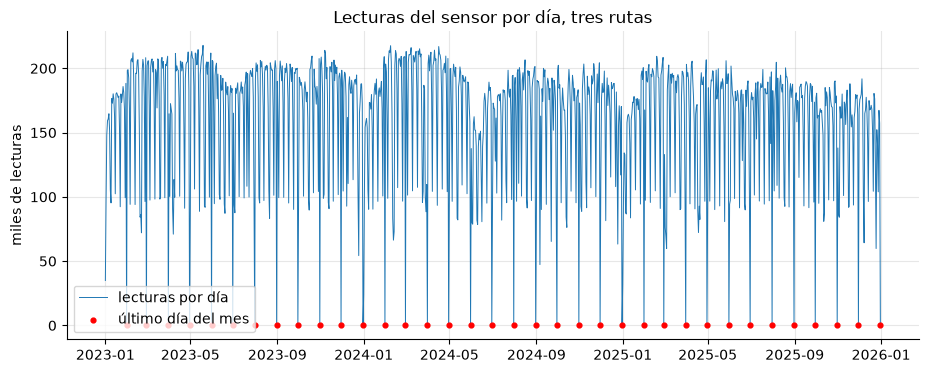

Mediana diaria (tres rutas):
                    lecturas  subidas_sensores  pasajeros_segun_viajes
resto de días       180032.0           44025.0                 41454.0
último día del mes      15.0               4.0                 43764.0

Días-ruta sin lecturas: 108 (en el último día del mes: 108)
Otros días sin lecturas: ninguno


In [2]:
crudo["fecha"] = crudo["ts"].dt.normalize()
todos = pd.date_range("2023-01-01", "2025-12-31")
lect = crudo.groupby(["fecha", "id_ruta"])["lecturas"].sum().unstack().reindex(todos).fillna(0)
tot = lect.sum(axis=1)
fin_mes = tot[tot.index.is_month_end]

fig, ax = plt.subplots()
ax.plot(tot.index, tot / 1e3, lw=0.7, label="lecturas por día")
ax.scatter(fin_mes.index, fin_mes / 1e3, color="red", s=12, zorder=3, label="último día del mes")
ax.set_ylabel("miles de lecturas"); ax.set_title("Lecturas del sensor por día, tres rutas"); ax.legend()
plt.show()

v_ok = viajes[viajes["cancelada"] == "N"]
comp = pd.DataFrame({
    "lecturas": tot,
    "subidas_sensores": crudo.groupby("fecha")["subidas"].sum().reindex(todos).fillna(0),
    "pasajeros_segun_viajes": v_ok.groupby(v_ok["fechasalida"].dt.normalize())["numeropasajeros"].sum(),
})
print("Mediana diaria (tres rutas):")
print(comp.groupby(np.where(comp.index.is_month_end, "último día del mes", "resto de días")).median().round(0))

sin_datos = lect < md.MIN_FRACCION_LECTURAS_DIA * lect.median()
print(f"\nDías-ruta sin lecturas: {int(sin_datos.values.sum())} "
      f"(en el último día del mes: {int(sin_datos[sin_datos.index.is_month_end].values.sum())})")
otros = sin_datos[~sin_datos.index.is_month_end].stack()
print("Otros días sin lecturas:", [f"{d:%Y-%m-%d} ruta {r}" for d, r in otros[otros].index] or "ninguno")

**Hallazgo:** el último día de cada mes la tabla de sensores está prácticamente vacía, aunque los viajes sí se hicieron (`progvehiculos` registra un número normal de pasajeros esos días). Es un hueco de la extracción, no ausencia de demanda.

**Regla:** los días con menos del 5 % de las lecturas habituales de la ruta se tratan como **faltantes**, no como cero. Si se dejaran en cero, el modelo aprendería que la demanda desaparece a fin de mes.

### 2.2 Lecturas imposibles

Máximo de subidas en una sola lectura, por franja:
count    243508.0
mean          2.4
std         205.4
min           0.0
50%           2.0
99%           7.0
99.9%        36.0
max       97154.0


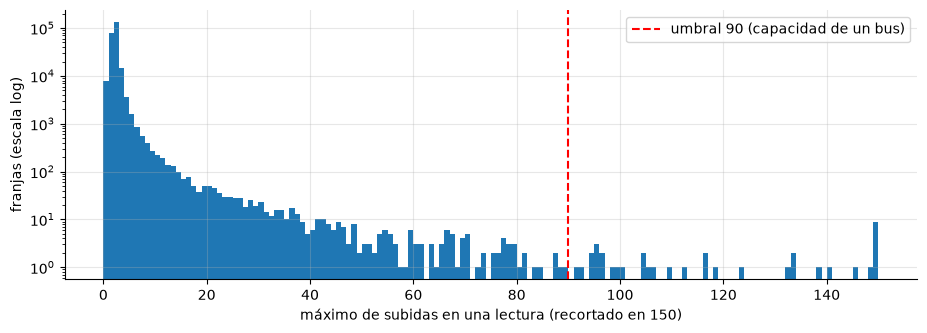


Franjas con alguna lectura > 90: 38 de 243,508 (0.016%), con 140,341 subidas (0.3% del total)
 id_ruta                  ts  subidas  lecturas  max_subida_lectura
      16 2024-05-26 12:45:00  97323.0       820               97154
      16 2025-07-05 07:45:00  29038.0      1458               28782
       2 2025-02-26 12:45:00    687.0       749                 497
      16 2025-10-04 11:15:00    727.0      1314                 421
      16 2023-06-09 15:45:00    712.0      1501                 292


In [3]:
m = crudo["max_subida_lectura"]
print("Máximo de subidas en una sola lectura, por franja:")
print(m.describe(percentiles=[0.5, 0.99, 0.999]).round(1).to_string())

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.hist(m.clip(upper=150), bins=150, log=True)
ax.axvline(md.MAX_SUBIDAS_LECTURA, color="red", ls="--", label=f"umbral {md.MAX_SUBIDAS_LECTURA} (capacidad de un bus)")
ax.set_xlabel("máximo de subidas en una lectura (recortado en 150)"); ax.set_ylabel("franjas (escala log)"); ax.legend()
plt.show()

malas = crudo[m > md.MAX_SUBIDAS_LECTURA]
print(f"\nFranjas con alguna lectura > {md.MAX_SUBIDAS_LECTURA}: {len(malas)} de {len(crudo):,} "
      f"({len(malas) / len(crudo):.3%}), con {malas['subidas'].sum():,.0f} subidas "
      f"({malas['subidas'].sum() / crudo['subidas'].sum():.1%} del total)")
print(malas.nlargest(5, "max_subida_lectura")[["id_ruta", "ts", "subidas", "lecturas", "max_subida_lectura"]].to_string(index=False))

**Hallazgo:** una lectura del sensor (cerca de un minuto) casi siempre registra entre 1 y 4 subidas, pero hay unas pocas franjas con lecturas de miles de subidas: son saltos del contador acumulado. Con tan pocas franjas y tanto peso, distorsionan cualquier promedio o correlación.

**Regla:** se descarta la franja si alguna lectura supera 90 subidas, más de lo que cabe en un bus. Se pierde una fracción despreciable de franjas.

### 2.3 Bajadas

In [4]:
anual = (crudo[crudo["ts"] < "2026-01-01"].assign(anio=lambda d: d["ts"].dt.year)
         .groupby(["id_ruta", "anio"])[["subidas", "bajadas"]].sum())
anual["bajadas / subidas"] = (anual["bajadas"] / anual["subidas"]).round(2)
anual

subidas    bajadas  bajadas / subidas
id_ruta anio                                         
2       2023  4342463.0  4239666.0               0.98
        2024  4010031.0  3903673.0               0.97
        2025  3672223.0  3575208.0               0.97
16      2023  8564314.0  8402650.0               0.98
        2024  7934549.0  7860130.0               0.99
        2025  7406734.0  8600096.0               1.16
21      2023  2757218.0  6328236.0               2.30
        2024  2660248.0  4687310.0               1.76
        2025  2418173.0  2402316.0               0.99

**Hallazgo:** en un recorrido completo deberían bajar tantas personas como suben (cociente cercano a 1). La ruta 21 registra más del doble de bajadas que de subidas en 2023 y 1,8 veces en 2024; la ruta 16 un 16 % de más en 2025. El sensor de bajadas no es confiable. **Las bajadas no se usan como objetivo ni como variable.**

### 2.4 Horario: sensores frente a `timbradas_segmentos`

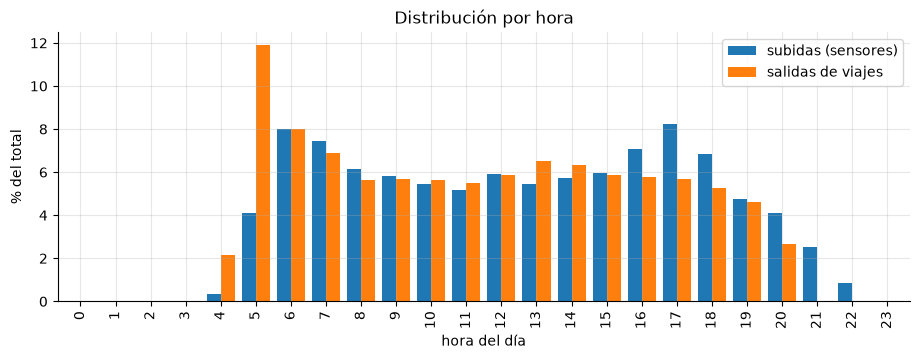

In [5]:
por_hora = pd.DataFrame({
    "subidas (sensores)": crudo.groupby(crudo["ts"].dt.hour)["subidas"].sum(),
    "salidas de viajes": viajes.groupby(viajes["fechasalida"].dt.hour).size(),
}).reindex(range(24)).fillna(0)
(por_hora / por_hora.sum() * 100).plot.bar(figsize=(11, 3.5), width=0.8)
plt.ylabel("% del total"); plt.xlabel("hora del día"); plt.title("Distribución por hora")
plt.show()

**Hallazgo:** en los sensores el servicio empieza hacia las 4:30 (coincide con el primer despacho de las rutas) y la demanda tiene picos a las 6–7 y a las 17 h. `timbradas_segmentos` pone esos picos a las 10 y a las 19–20 h y tiene un bloque a la 1 a. m. que no existe en los sensores ni en los despachos. Al comparar franja por franja, la correlación entre ambas fuentes sube de 0,47 a 0,71 si se corren los sensores 2 horas: **las horas de `timbradas_segmentos` están desplazadas**. Además esa tabla solo cubre 8 semanas. Por ambas razones se reemplaza por los sensores.

### 2.5 Viajes cancelados

In [6]:
print(viajes.groupby(viajes["fechasalida"].dt.year)["cancelada"].apply(lambda s: f"{(s == 'S').mean():.1%}"))

fechasalida
2023    6.7%
2024    8.0%
2025    8.8%
Name: cancelada, dtype: str


Entre el 7 % y el 9 % de los viajes programados se cancelan, y la tasa crece cada año. No afecta al objetivo (los sensores solo registran viajes que ocurrieron).

### Aplicación de las reglas de limpieza
Desde aquí se trabaja con los datos limpios, con la misma función que usa el entrenamiento.

In [7]:
datos = md.limpiar_demanda(crudo.drop(columns="fecha"))
serie = md.preparar_serie(datos)
obs = serie[serie["observado"]].copy()
obs["fecha"] = obs["ts"].dt.normalize()
diario = obs.groupby(["fecha", "id_ruta"])["subidas"].sum().unstack()   # los días sin datos quedan NaN
fest = md._dias_en_rangos(estac[estac["estacionalidad"] == "FESTIVO_NACIONAL"])
print(f"{len(obs):,} franjas con servicio | {diario.notna().sum().to_dict()} días con datos por ruta")

Limpieza: 107 dias-ruta sin lecturas del sensor y 38 franjas con lecturas imposibles -> faltantes


243,001 franjas con servicio | {2: 1060, 16: 1060, 21: 1060} días con datos por ruta


## 3. Tendencia: la demanda cae año a año

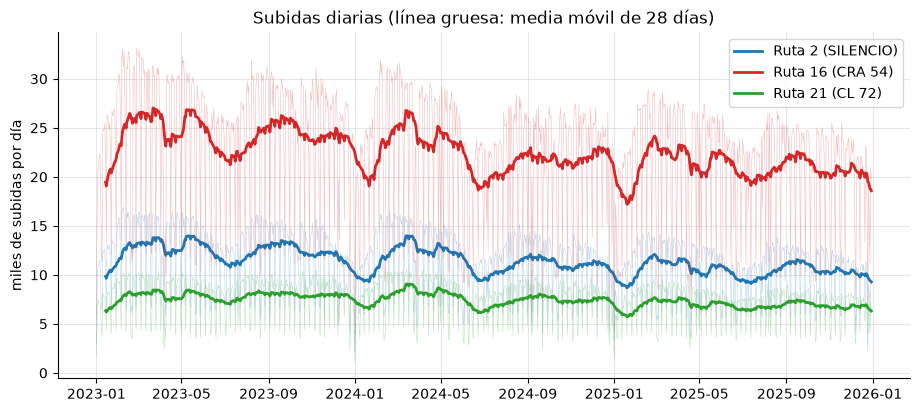

Subidas promedio por día:
id_ruta      2     16    21 var. 2 var. 16 var. 21
fecha                                             
2023     12297  24258  7808                       
2024     11322  22128  7514  -7.9%   -8.8%   -3.8%
2025     10401  20891  6849  -8.1%   -5.6%   -8.8%

Oferta:
            viajes_por_dia          pasajeros_por_viaje            
id_ruta                 2    16  21                  2     16    21
fechasalida                                                        
2023                   138  272  85                80.0  84.0  84.0
2024                   131  255  85                76.0  83.0  82.0
2025                   132  247  81                68.0  78.0  77.0


In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for r in diario:
    ax.plot(diario.index, diario[r] / 1e3, lw=0.4, alpha=0.3, color=COLORES[r])
    ax.plot(diario.index, diario[r].rolling(28, min_periods=14).mean() / 1e3, lw=2, color=COLORES[r], label=NOMBRE[r])
ax.set_ylabel("miles de subidas por día"); ax.set_title("Subidas diarias (línea gruesa: media móvil de 28 días)")
ax.legend(); plt.show()

media_anual = diario.groupby(diario.index.year).mean()
tabla = media_anual.round(0).astype(int).astype(str)
for r in diario:
    tabla[f"var. {r}"] = media_anual[r].pct_change().map(lambda x: "" if pd.isna(x) else f"{x:+.1%}")
print("Subidas promedio por día:")
print(tabla)

v = viajes[viajes["cancelada"] == "N"]
oferta = v.groupby(["id_ruta", v["fechasalida"].dt.year]).agg(
    viajes_por_dia=("idprogramacion", lambda s: round(len(s) / 365)),
    pasajeros_por_viaje=("numeropasajeros", "median"))
print("\nOferta:")
print(oferta.unstack(0))

**Hallazgo:** la demanda cae entre 3 % y 9 % por año en las tres rutas, y a la vez caen los viajes por día y los pasajeros por viaje. Un modelo de árboles no extrapola tendencias, así que necesita una **variable de nivel reciente** (demanda media de los últimos 28 días) para no quedarse anclado en el nivel de 2023.

## 4. Estacionalidad anual

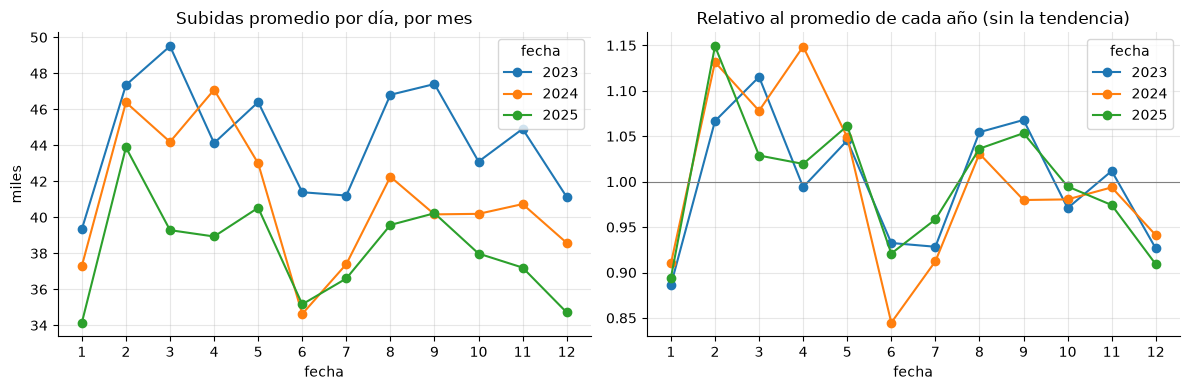

fecha  2023  2024  2025
fecha                  
1      0.89  0.91  0.89
2      1.07  1.13  1.15
3      1.12  1.08  1.03
4      0.99  1.15  1.02
5      1.05  1.05  1.06
6      0.93  0.84  0.92
7      0.93  0.91  0.96
8      1.05  1.03  1.04
9      1.07  0.98  1.05
10     0.97  0.98  0.99
11     1.01  0.99  0.97
12     0.93  0.94  0.91


In [9]:
tot_dia = diario.sum(axis=1, min_count=3)          # solo días con las tres rutas
mensual = tot_dia.groupby([tot_dia.index.month, tot_dia.index.year]).mean().unstack()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
(mensual / 1e3).plot(ax=axes[0], marker="o")
axes[0].set_title("Subidas promedio por día, por mes"); axes[0].set_ylabel("miles"); axes[0].set_xticks(range(1, 13))
(mensual / mensual.mean()).plot(ax=axes[1], marker="o")
axes[1].axhline(1, color="grey", lw=0.8)
axes[1].set_title("Relativo al promedio de cada año (sin la tendencia)"); axes[1].set_xticks(range(1, 13))
plt.tight_layout(); plt.show()
print((mensual / mensual.mean()).round(2))

**Hallazgo:** con la tendencia quitada, la forma del año se repite: **enero, junio–julio y diciembre** están por debajo del promedio (vacaciones escolares y universitarias) y **febrero–mayo y agosto–septiembre** por encima. Con tres años esto ya se puede aprender: se agregan el **día del año** y la **demanda de la misma franja 52 semanas antes** (mismo día de la semana).

## 5. Patrón semanal y festivos

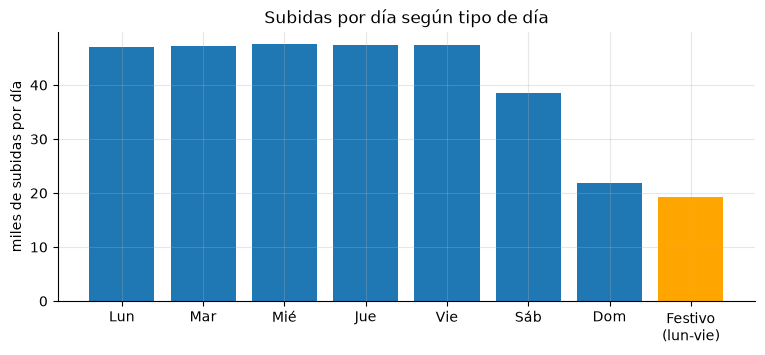

Sábado: 81% de un día hábil | Domingo: 46% | Festivo: 41%


In [10]:
t = tot_dia.dropna().to_frame("subidas")
t["dia"] = t.index.dayofweek
t["festivo"] = t.index.isin(fest)
semana = t[~t["festivo"]].groupby("dia")["subidas"].mean()
festivo_habil = t[t["festivo"] & (t["dia"] < 5)]["subidas"].mean()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar([DIAS[i] for i in semana.index], semana / 1e3)
ax.bar(["Festivo\n(lun-vie)"], [festivo_habil / 1e3], color="orange")
ax.set_ylabel("miles de subidas por día"); ax.set_title("Subidas por día según tipo de día")
plt.show()
habil = semana.loc[0:4].mean()
print(f"Sábado: {semana[5] / habil:.0%} de un día hábil | Domingo: {semana[6] / habil:.0%} | Festivo: {festivo_habil / habil:.0%}")

**Hallazgo:** los días hábiles son muy parecidos entre sí; el sábado cae poco y el domingo cae a menos de la mitad. Un festivo entre semana se comporta como un domingo. De ahí la variable **`tipo_dia`** (hábil / sábado / domingo o festivo), que agrupa días con la misma forma.

## 6. Calendario: festivos, Carnaval, Semana Santa y eventos

In [11]:
# Demanda del día frente a la mediana del mismo día de la semana en las 4 semanas previas
base = pd.concat([tot_dia.shift(7 * k, freq="D") for k in range(1, 5)], axis=1).median(axis=1)
ratio = (tot_dia / base.reindex(tot_dia.index)).dropna()

filas = []
for _, e in estac.iterrows():
    for d in pd.date_range(e["fecha_inicio"], e["fecha_fin"]):
        if d in ratio.index:
            filas.append({"tipo": e["estacionalidad"], "id": e["id_estacionalidad"], "fecha": d,
                          "anio": d.year, "habil": d.dayofweek < 5, "ratio": ratio[d]})
ev = pd.DataFrame(filas)
nombres = {7: "Precarnaval", 8: "Carnaval (días centrales)", 10: "Semana Santa", 27: "Fiestas patronales"}
ev["evento"] = ev["id"].map(nombres).fillna(ev["tipo"].map({"FESTIVO_NACIONAL": "Festivo nacional"}))
resumen = ev[ev["habil"]].groupby(["evento", "anio"])["ratio"].mean().unstack().round(2)
print("Demanda en días hábiles del evento / demanda habitual de ese día de la semana:")
print(resumen)

Demanda en días hábiles del evento / demanda habitual de ese día de la semana:
anio                       2023  2024  2025
evento                                     
Carnaval (días centrales)  0.41  0.42  0.35
Festivo nacional           0.46  0.45  0.40
Fiestas patronales          NaN  1.05  1.02
Precarnaval                1.13  1.24  1.05
Semana Santa               0.59  0.51  0.60


C:\Users\USER\AppData\Local\Temp\ipykernel_16228\749975698.py:2: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  base = pd.concat([tot_dia.shift(7 * k, freq="D") for k in range(1, 5)], axis=1).median(axis=1)


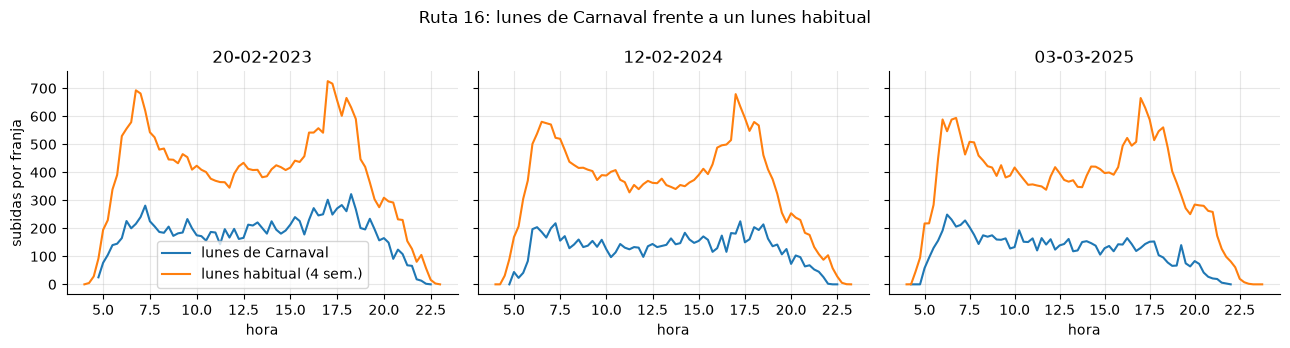

In [12]:
# Perfil del lunes de Carnaval frente a un lunes habitual, ruta 16
r16 = obs[obs["id_ruta"] == 16].set_index("ts")["subidas"]


def perfil_dia(s, dia):
    x = s[dia: dia + pd.Timedelta(hours=23, minutes=45)]
    return pd.Series(x.values, index=(x.index - dia).total_seconds() / 3600)


inicios = pd.to_datetime(estac.loc[estac["id_estacionalidad"] == md.ID_CARNAVAL_CENTRAL, "fecha_inicio"])
lunes_carnaval = sorted(d + pd.Timedelta(days=2) for d in inicios if 2023 <= d.year <= 2025)  # empiezan en sábado
fig, axes = plt.subplots(1, len(lunes_carnaval), figsize=(13, 3.5), sharey=True)
for ax, lunes in zip(axes, lunes_carnaval):
    habitual = pd.concat([perfil_dia(r16, lunes - pd.Timedelta(days=7 * k)) for k in range(1, 5)], axis=1).mean(axis=1).sort_index()
    perfil_dia(r16, lunes).plot(ax=ax, label="lunes de Carnaval")
    habitual.plot(ax=ax, label="lunes habitual (4 sem.)")
    ax.set_title(f"{lunes:%d-%m-%Y}"); ax.set_xlabel("hora")
axes[0].set_ylabel("subidas por franja"); axes[0].legend()
plt.suptitle("Ruta 16: lunes de Carnaval frente a un lunes habitual"); plt.tight_layout(); plt.show()

In [13]:
# Eventos con hora (novedades_viales_fecha): demanda en la ventana del evento frente a lo habitual
tot_franja = obs.groupby("ts")["subidas"].sum()
filas = []
for _, n in novedades.iterrows():
    f = pd.Timestamp(n["fecha"])
    if f.year > 2025:
        continue
    ini, fin = f + pd.to_timedelta(str(n["hora_inicio"])), f + pd.to_timedelta(str(n["hora_fin"]))
    real = tot_franja[ini:fin].sum()
    habitual = np.mean([tot_franja[ini - pd.Timedelta(days=7 * k): fin - pd.Timedelta(days=7 * k)].sum() for k in range(1, 5)])
    filas.append({"fecha": f.date(), "evento": n["evento"], "ventana": f"{n['hora_inicio']}-{n['hora_fin']}",
                  "impacto_declarado": n["porcentaje_impacto"], "ratio_real": round(real / habitual, 2) if habitual else None})
print(pd.DataFrame(filas).to_string(index=False))

     fecha                           evento           ventana  impacto_declarado  ratio_real
2023-02-10                        Guacherna 19:00:00-23:59:00               80.0        0.81
2023-02-18                Batalla de Flores 11:30:00-18:00:00               95.0        0.87
2023-02-18                         Carnaval 00:00:00-23:59:00              100.0        0.89
2023-02-19                         Carnaval 00:00:00-23:59:00              100.0        0.89
2023-02-20                         Carnaval 00:00:00-23:59:00              100.0        0.43
2023-02-21                         Carnaval 00:00:00-23:59:00               90.0        0.53
2023-09-07 Partido de la Selección Colombia 18:00:00-21:00:00               85.0        0.83
2023-10-12 Partido de la Selección Colombia 15:30:00-18:30:00               85.0        0.64
2023-11-16 Partido de la Selección Colombia 19:00:00-22:00:00               90.0        0.76
2024-02-02                        Guacherna 18:00:00-23:59:00         

**Hallazgos:**
- Los **días centrales de Carnaval** en día hábil (lunes y martes) dejan la demanda en 35–42 % de lo normal, igual los tres años, y el perfil del día pierde los dos picos: se comportan como festivo (40–46 %). Por eso cuentan como `tipo_dia` = festivo, y además tienen su propia variable `carnaval_central`.
- El **precarnaval** no baja la demanda: la **sube** entre 5 % y 24 %. Se deja como indicador (`precarnaval`).
- En **Semana Santa** los días hábiles quedan en 51–60 % de lo normal (incluye los festivos de jueves y viernes santos): se agrega la variable `semana_santa`.
- Las **fiestas patronales** (Puerto Colombia) no mueven la demanda de estas rutas (≈ 1,0): no se usan.
- En su ventana horaria, los **partidos de la Selección** bajan la demanda entre 17 % y 37 % (la gente se queda a verlos) y la **Guacherna** entre 6 % y 19 %. Son pocos eventos; su efecto entra con `impacto_evento`.

## 7. Perfil dentro del día

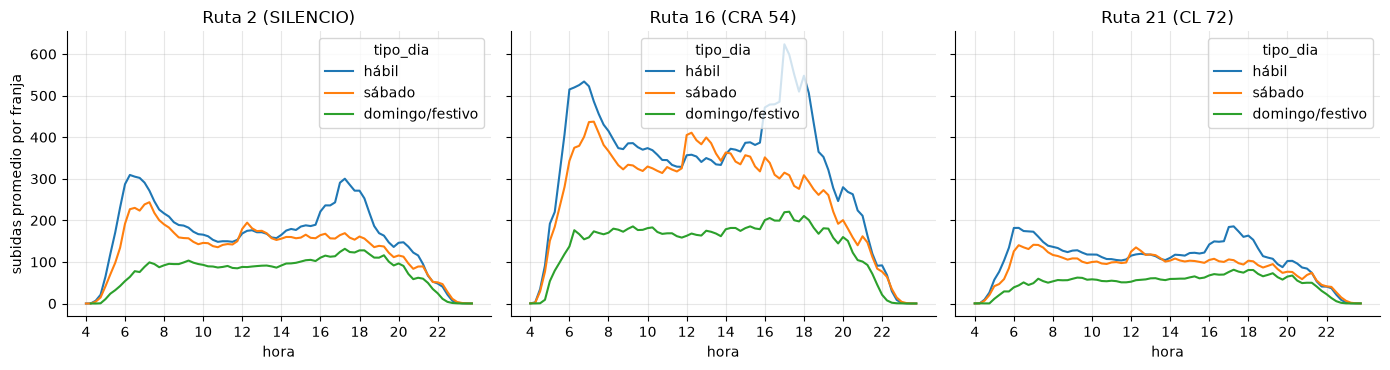

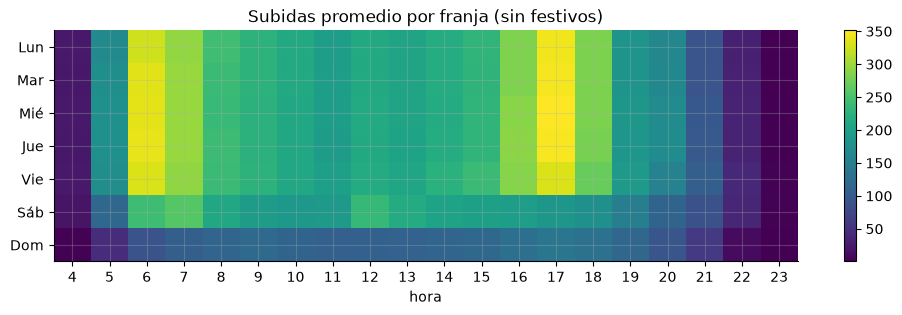

In [14]:
obs["tipo_dia"] = np.where(obs["ts"].dt.normalize().isin(fest) | (obs["ts"].dt.dayofweek == 6), "domingo/festivo",
                           np.where(obs["ts"].dt.dayofweek == 5, "sábado", "hábil"))
obs["hora_dec"] = obs["ts"].dt.hour + obs["ts"].dt.minute / 60
servicio = obs[obs["ts"].dt.hour >= 4]          # de 0 a 4 h solo hay lecturas sueltas
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
for ax, r in zip(axes, sorted(obs["id_ruta"].unique())):
    perfil = servicio[servicio["id_ruta"] == r].groupby(["tipo_dia", "hora_dec"])["subidas"].mean().unstack(0)
    perfil[["hábil", "sábado", "domingo/festivo"]].plot(ax=ax)
    ax.set_title(NOMBRE[r]); ax.set_xlabel("hora"); ax.set_xticks(range(4, 24, 2))
axes[0].set_ylabel("subidas promedio por franja")
plt.tight_layout(); plt.show()

sin_fest = servicio[~servicio["ts"].dt.normalize().isin(fest)]
mapa = sin_fest.pivot_table(index=sin_fest["ts"].dt.dayofweek, columns=sin_fest["ts"].dt.hour,
                            values="subidas", aggfunc="mean")
fig, ax = plt.subplots(figsize=(12, 3))
im = ax.imshow(mapa.values, aspect="auto", cmap="viridis")
ax.set_yticks(range(7)); ax.set_yticklabels(DIAS); ax.set_xticks(range(len(mapa.columns))); ax.set_xticklabels(mapa.columns)
ax.set_xlabel("hora"); ax.set_title("Subidas promedio por franja (sin festivos)"); plt.colorbar(im, ax=ax)
plt.show()

**Hallazgo:** el día hábil tiene dos picos (mañana 6–7 h y tarde 17 h); el fin de semana el pico de la mañana se aplana y se corre. La forma cambia por ruta y por tipo de día, así que el modelo necesita la hora (`minuto_dia`) combinada con `tipo_dia` e `id_ruta`; un árbol aprende esas interacciones sin construirlas a mano.

## 8. Oferta de viajes

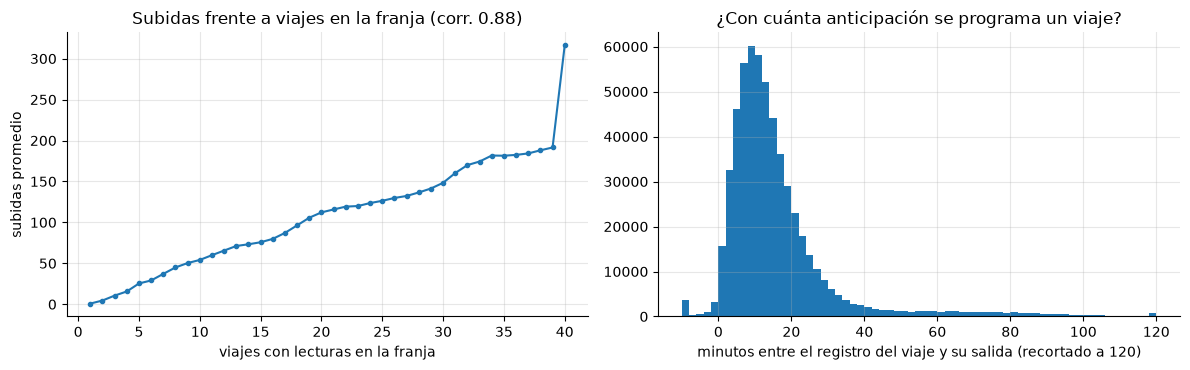

Anticipación mediana: 12 min | viajes registrados con 30 min o más: 9.3% | con 2 h o más: 0.12%


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
b = obs.groupby(obs["nro_viajes"].clip(upper=40))["subidas"].mean()
axes[0].plot(b.index, b.values, marker=".")
axes[0].set_xlabel("viajes con lecturas en la franja"); axes[0].set_ylabel("subidas promedio")
axes[0].set_title(f"Subidas frente a viajes en la franja (corr. {obs['subidas'].corr(obs['nro_viajes']):.2f})")

anticip = (viajes["fechasalida"] - viajes["fecharegistro"]).dt.total_seconds() / 60
axes[1].hist(anticip.clip(-10, 120), bins=65)
axes[1].set_xlabel("minutos entre el registro del viaje y su salida (recortado a 120)")
axes[1].set_title("¿Con cuánta anticipación se programa un viaje?")
plt.tight_layout(); plt.show()
print(f"Anticipación mediana: {anticip.median():.0f} min | viajes registrados con 30 min o más: {(anticip >= 30).mean():.1%} "
      f"| con 2 h o más: {(anticip >= 120).mean():.2%}")

**Hallazgo:** más viajes en la franja van con más subidas (la oferta sigue a la demanda y viceversa), pero **los viajes se registran unos 12 minutos antes de salir**: al predecir a 30–120 minutos, los viajes de la franja objetivo todavía no existen. Usarlos sería fuga de información. Sí se pueden usar los **viajes de la última hora conocida** y los **viajes habituales** de esa franja en las 4 semanas previas.

## 9. ¿Qué información predice mejor la demanda?

In [16]:
filas = []
for r in sorted(serie["id_ruta"].unique()):
    s = serie[serie["id_ruta"] == r].set_index("ts")["subidas"]
    fila = {"ruta": r}
    for nombre, k in [("15 min", 1), ("30 min", 2), ("1 h", 4), ("2 h", 8), ("1 día", 96), ("7 días", 672), ("364 días", 96 * 364)]:
        fila[nombre] = round(s.corr(s.shift(k)), 3)
    prom4 = pd.concat([s.shift(672 * k) for k in range(1, 5)], axis=1).mean(axis=1)
    fila["prom. 4 semanas"] = round(s.corr(prom4), 3)
    filas.append(fila)
print("Correlación de las subidas de una franja con el dato de hace ...")
print(pd.DataFrame(filas).set_index("ruta").to_string())

Correlación de las subidas de una franja con el dato de hace ...
      15 min  30 min    1 h    2 h  1 día  7 días  364 días  prom. 4 semanas
ruta                                                                        
2      0.932   0.867  0.671  0.311  0.720   0.833     0.841            0.880
16     0.947   0.893  0.749  0.432  0.691   0.836     0.846            0.882
21     0.881   0.815  0.651  0.369  0.632   0.760     0.767            0.832


**Hallazgo:** con los datos limpios la demanda es muy predecible, pero lo que más sirve depende del horizonte:
- A **30 minutos**, el dato más reciente (0,82–0,89) vale tanto como el **promedio de 4 semanas** (0,83–0,88).
- A **2 horas**, el dato reciente pierde casi todo su valor (0,31–0,43) y manda el patrón habitual.
- El dato de **un año antes** (0,77–0,85) vale tanto como el de una semana antes: la estacionalidad anual es real.

Por eso el modelo combina rezagos recientes (hasta la referencia), diarios, semanales y anuales, y se entrena un modelo por horizonte.

## 10. Conclusiones para el modelado

| Hallazgo | Decisión |
|---|---|
| El último día de cada mes no tiene lecturas del sensor | Esos días son **faltantes**, no cero |
| Hay lecturas imposibles (saltos del contador) | Se descarta la franja si una lectura supera 90 subidas |
| Las bajadas no cuadran con las subidas (ruta 21) | No se usan |
| `timbradas_segmentos` cubre 8 semanas y tiene las horas corridas | Se reemplaza por los sensores: **3 años** |
| La demanda cae 3–9 % por año | Variable de **nivel reciente** (`nivel_28d`) |
| Estacionalidad anual estable (vacaciones en ene, jun–jul, dic) | `dia_del_anio` y `lag_364d` |
| Sábado, domingo y festivo tienen formas distintas | `tipo_dia` |
| Carnaval central y Semana Santa bajan la demanda | `carnaval_central`, `semana_santa` |
| La oferta de la franja futura no se conoce (se registra 12 min antes) | Solo `viajes_1h_previa` y `viajes_habituales` |
| El dato reciente sirve a 30 min pero no a 2 h; el promedio de 4 semanas y el de hace un año sirven siempre | Rezagos recientes, diarios, semanales y anuales; un modelo por horizonte |

El detalle de cada variable, la verificación de que ninguna usa información futura y su aporte al modelo están en `feature_engineering.ipynb`.